In [1]:
import os
import pandas as pd
import numpy as np
import shutil
from sklearn.model_selection import train_test_split
from tqdm import tqdm

In [2]:
path = "C:\\Users\\Sabbir\\.cache\\kagglehub\\datasets\\nih-chest-xrays\\data\\versions\\3"

In [3]:
import pandas as pd

df_bbox = pd.read_csv('/Users/ahsanurrahman/Antigravity/NIH/small_nih_dataset/Bbox_List_2017.csv')
display(df_bbox.head())

,Image Index,Finding Label,Bbox [x,y,w,h],Unnamed: 6,Unnamed: 7,Unnamed: 8
0,00000211_010.png,Atelectasis,353.084746,535.087013,101.966102,168.135593,NaN,NaN,NaN
1,00015770_010.png,Cardiomegaly,363.932203,470.002268,451.254237,271.186441,NaN,NaN,NaN
2,00029808_003.png,Cardiomegaly,321.627119,410.341251,446.915254,394.847458,NaN,NaN,NaN
3,00015064_001.png,Cardiomegaly,379.259259,449.693122,603.564021,516.876190,NaN,NaN,NaN
4,00004342_023.png,Cardiomegaly,342.416931,435.606349,455.111111,378.175661,NaN,NaN,NaN


In [4]:
import os
import glob
import cv2
import math
import time
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from tqdm import tqdm
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import roc_auc_score

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

In [5]:
path = "/Users/ahsanurrahman/Antigravity/NIH/small_nih_dataset"

In [6]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


In [7]:
base_dir = path # Use the correct path from the kagglehub download
print(os.listdir(base_dir)[:20])

['images', 'Data_Entry_2017.csv', 'BBox_List_2017.csv']


In [8]:
data_csv = os.path.join(base_dir, "Data_Entry_2017.csv")
bbox_csv = os.path.join(base_dir, "BBox_List_2017.csv")

df = pd.read_csv(data_csv)
bbox_df = pd.read_csv(bbox_csv)

print(df.shape)
print(bbox_df.shape)
df.head()

(1000, 12)
(11, 9)


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
0,00022260_003.png,No Finding,3,22260,54,F,PA,2542,2434,0.143,0.143,NaN
1,00012048_007.png,Infiltration|Mass|Nodule,7,12048,65,M,AP,2500,2048,0.168,0.168,NaN
2,00014352_005.png,No Finding,5,14352,6,M,PA,2992,2033,0.143,0.143,NaN
3,00006040_001.png,No Finding,1,6040,18,F,AP,2500,2048,0.171,0.171,NaN
4,00011202_002.png,No Finding,2,11202,19,M,AP,2500,2048,0.168,0.168,NaN


In [9]:
image_paths = glob.glob(os.path.join(base_dir, "images*", "**", "*.png"), recursive=True)
image_index = {os.path.basename(x): x for x in image_paths}

df["path"] = df["Image Index"].map(image_index)
df = df.dropna(subset=["path"]).reset_index(drop=True)

bbox_df["path"] = bbox_df["Image Index"].map(image_index)
bbox_df = bbox_df.dropna(subset=["path"]).reset_index(drop=True)

print("Images found:", len(image_index))
print("Usable df rows:", len(df))
print("Usable bbox rows:", len(bbox_df))

Images found: 352
Usable df rows: 352
Usable bbox rows: 2


In [10]:
all_labels = [
    "Atelectasis", "Cardiomegaly", "Effusion", "Infiltration",
    "Mass", "Nodule", "Pneumonia", "Pneumothorax",
    "Consolidation", "Edema", "Emphysema", "Fibrosis",
    "Pleural_Thickening", "Hernia"
]

for c in all_labels:
    df[c] = df["Finding Labels"].apply(lambda x: 1 if c in x else 0)

df["No Finding"] = df["Finding Labels"].apply(lambda x: 1 if x == "No Finding" else 0)

df[all_labels].sum().sort_values(ascending=False)

Infiltration          54
Effusion              43
Atelectasis           37
Mass                  17
Pneumothorax          14
Consolidation         14
Cardiomegaly          13
Nodule                13
Pleural_Thickening    10
Fibrosis               9
Pneumonia              4
Edema                  4
Emphysema              2
Hernia                 0
dtype: int64

In [11]:
df["Patient ID"] = df["Patient ID"].astype(str)

keep_cols = ["Image Index", "Patient ID", "path", "Finding Labels"] + all_labels
df = df[keep_cols].copy()

df.head()

,Image Index,Patient ID,path,Finding Labels,Atelectasis,Cardiomegaly,Effusion,Infiltration,Mass,Nodule,Pneumonia,Pneumothorax,Consolidation,Edema,Emphysema,Fibrosis,Pleural_Thickening,Hernia
0,00006040_001.png,6040,/Users/ahsanurrahman/Antigravity/NIH/small_nih...,No Finding,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,00002275_007.png,2275,/Users/ahsanurrahman/Antigravity/NIH/small_nih...,Emphysema|Infiltration|Pneumothorax,0,0,0,1,0,0,0,1,0,0,1,0,0,0
2,00003446_008.png,3446,/Users/ahsanurrahman/Antigravity/NIH/small_nih...,No Finding,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,00004640_000.png,4640,/Users/ahsanurrahman/Antigravity/NIH/small_nih...,No Finding,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,00008858_007.png,8858,/Users/ahsanurrahman/Antigravity/NIH/small_nih...,Effusion,0,0,1,0,0,0,0,0,0,0,0,0,0,0


In [12]:
splitter = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
train_idx, val_idx = next(splitter.split(df, groups=df["Patient ID"]))

train_df = df.iloc[train_idx].reset_index(drop=True)
val_df   = df.iloc[val_idx].reset_index(drop=True)

print("Train:", train_df.shape)
print("Val:", val_df.shape)
print("Train patients:", train_df["Patient ID"].nunique())
print("Val patients:", val_df["Patient ID"].nunique())

Train: (297, 18)
Val: (55, 18)
Train patients: 273
Val patients: 49


In [13]:
USE_SUBSET = False

In [14]:
from torchvision import transforms
IMG_SIZE = 384
BATCH_SIZE = 32

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(7),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.485,0.485], [0.229,0.229,0.229])
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.485,0.485], [0.229,0.229,0.229])
])

In [15]:
class NIHChestDataset(Dataset):
    def __init__(self, dataframe, labels, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = row["path"]

        # Safety check to avoid crashing on stale/missing paths.
        if not isinstance(img_path, str) or not os.path.exists(img_path):
            idx = (idx + 1) % len(self.df)
            row = self.df.iloc[idx]
            img_path = row["path"]

        img = Image.open(img_path).convert("L")  # grayscale
        img = np.array(img)
        img = np.stack([img, img, img], axis=-1)    # convert to 3-channel

        img = Image.fromarray(img.astype(np.uint8))
        if self.transform:
            img = self.transform(img)

        target = torch.tensor(row[self.labels].values.astype(np.float32))
        return img, target, img_path

In [16]:
# Drop rows that point to files that are no longer present on disk
train_df = train_df[train_df["path"].map(os.path.exists)].reset_index(drop=True)
val_df = val_df[val_df["path"].map(os.path.exists)].reset_index(drop=True)

print("Train rows with existing images:", len(train_df))
print("Val rows with existing images:", len(val_df))

train_dataset = NIHChestDataset(train_df, all_labels, transform=train_transform)
val_dataset   = NIHChestDataset(val_df, all_labels, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0)

print(len(train_loader), len(val_loader))

Train rows with existing images: 297
Val rows with existing images: 55
10 2


In [17]:
import torch.nn.functional as F
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models

class DenseNetMultiLabel(nn.Module):
    def __init__(self, num_classes=14):
        super().__init__()
        original_densenet = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)

        # Extract features and replace classifier
        self.features = original_densenet.features
        in_features = original_densenet.classifier.in_features
        self.classifier = nn.Linear(in_features, num_classes)

        # Crucial: Modify all ReLU layers in the features extractor to be not in-place
        for module in self.features.modules():
            if isinstance(module, nn.ReLU):
                module.inplace = False

    def forward(self, x):
        features = self.features(x)
        out = F.relu(features, inplace=False) # Ensure this F.relu is not in-place
        out = F.adaptive_avg_pool2d(out, (1, 1))
        out = torch.flatten(out, 1)
        out = self.classifier(out)
        return out

model = DenseNetMultiLabel(num_classes=len(all_labels)).to(device)
print("Model ready")

Model ready


In [18]:
# Freeze backbone
for param in model.features.parameters():
    param.requires_grad = False

# Unfreeze last block
for param in model.features.denseblock4.parameters():
    param.requires_grad = True

In [19]:
label_counts = train_df[all_labels].sum().values
total_samples = len(train_df)

pos_weights = []
for c in label_counts:
    pos = c
    neg = total_samples - c
    pos_weights.append(neg / (pos + 1e-6))

pos_weights = torch.tensor(pos_weights, dtype=torch.float32).to(device)
class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        pt = torch.exp(-bce)
        loss = self.alpha * (1 - pt) ** self.gamma * bce
        return loss.mean()

criterion = FocalLoss()

optimizer = torch.optim.AdamW([
    {"params": model.features.denseblock4.parameters(), "lr": 1e-5},
    {"params": model.classifier.parameters(), "lr": 1e-4}
])
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=1, factor=0.5)

In [ ]:
def compute_auc(y_true, y_prob):
    aucs = []
    for i in range(y_true.shape[1]):
        if len(np.unique(y_true[:, i])) < 2:
            continue
        auc = roc_auc_score(y_true[:, i], y_prob[:, i])
        aucs.append(auc)

    return np.mean(aucs) if len(aucs) > 0 else 0.0

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0

    for images, targets, _ in tqdm(loader):
        images = images.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    return running_loss / len(loader.dataset)

@torch.no_grad()
def validate_one_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_targets = []
    all_probs = []

    for images, targets, _ in tqdm(loader):
        images = images.to(device)
        targets = targets.to(device)

        outputs = model(images)
        loss = criterion(outputs, targets)

        probs = torch.sigmoid(outputs)

        running_loss += loss.item() * images.size(0)
        all_targets.append(targets.cpu().numpy())
        all_probs.append(probs.cpu().numpy())

    val_loss = running_loss / len(loader.dataset)
    all_targets = np.concatenate(all_targets, axis=0)
    all_probs = np.concatenate(all_probs, axis=0)
    mean_auc = compute_auc(all_targets, all_probs)

    return val_loss, mean_auc

In [21]:
EPOCHS = 50
best_auc = 0.0
best_model_wts = copy.deepcopy(model.state_dict())

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_auc = validate_one_epoch(model, val_loader, criterion, device)

    scheduler.step(val_loss)

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss  : {val_loss:.4f}")
    print(f"Val mAUC  : {val_auc:.4f}")

    if val_auc > best_auc:
        best_auc = val_auc
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save(model.state_dict(), "/Users/ahsanurrahman/Antigravity/NIH/model/best_densenet_nih.pth")
        print("Best model saved")

model.load_state_dict(best_model_wts)
print("Best AUC:", best_auc)


Epoch 1/50


100%|██████████| 2/2 [00:09<00:00,  4.68s/it]


Train Loss: 0.1701
Val Loss  : 0.1378
Val mAUC  : 0.6175
Best model saved

Epoch 2/50


100%|██████████| 2/2 [00:09<00:00,  4.78s/it]


Train Loss: 0.0952
Val Loss  : 0.0794
Val mAUC  : 0.6016

Epoch 3/50


...

Train Loss: 0.0455
Val Loss  : 0.0448
Val mAUC  : 0.5814

Epoch 15/50


100%|██████████| 2/2 [00:15<00:00,  7.52s/it]


Train Loss: 0.0451
Val Loss  : 0.0448
Val mAUC  : 0.5853

Epoch 16/50


 30%|███       | 3/10 [00:31<01:13, 10.49s/it]


KeyboardInterrupt: 

In [ ]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        self.forward_hook = target_layer.register_forward_hook(self.save_activation)
        self.backward_hook = target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output.clone().detach()  # Modified: Use .clone().detach()

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor, class_idx):
        self.model.zero_grad()
        output = self.model(input_tensor)
        score = output[:, class_idx].sum()
        score.backward(retain_graph=True)

        gradients = self.gradients
        activations = self.activations

        weights = gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * activations).sum(dim=1, keepdim=True)
        cam = torch.relu(cam)

        cam = cam[0, 0].cpu().numpy()
        cam = cv2.resize(cam, (IMG_SIZE, IMG_SIZE))

        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)

        return cam

In [ ]:
target_layer = model.features.denseblock4 # Correctly target the features of the DenseNetMultiLabel instance
grad_cam = GradCAM(model, target_layer)
print("Grad-CAM ready")

Grad-CAM ready


In [ ]:
def extract_bbox_from_cam(cam, threshold=0.5):
    cam_uint8 = np.uint8(cam * 255)
    _, thresh = cv2.threshold(cam_uint8, int(threshold * 255), 255, cv2.THRESH_BINARY)

    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if len(contours) == 0:
        return None

    largest = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(largest)
    return (x, y, x + w, y + h)

In [ ]:
def predict_with_bbox(model, image_path, target_label=None, threshold=0.3):
    model.eval()

    raw_img = Image.open(image_path).convert("L")
    raw_img = raw_img.resize((IMG_SIZE, IMG_SIZE))
    raw_np = np.array(raw_img)
    rgb_np = np.stack([raw_np, raw_np, raw_np], axis=-1)

    input_img = Image.fromarray(rgb_np.astype(np.uint8))
    tensor = val_transform(input_img).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(tensor)
        probs = torch.sigmoid(logits)[0].cpu().numpy()

    pred_idx = np.argmax(probs) if target_label is None else all_labels.index(target_label)
    pred_label = all_labels[pred_idx]
    pred_prob = probs[pred_idx]

    cam = grad_cam.generate(tensor, pred_idx)
    bbox = extract_bbox_from_cam(cam, threshold=threshold)

    return rgb_np, cam, bbox, pred_label, pred_prob, probs

In [ ]:
def show_prediction(image_path, target_label=None, threshold=0.3):
    rgb_np, cam, bbox, pred_label, pred_prob, probs = predict_with_bbox(
        model, image_path, target_label=target_label, threshold=threshold
    )

    overlay = rgb_np.copy()
    heatmap = np.uint8(255 * cam)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    blended = cv2.addWeighted(rgb_np, 0.6, heatmap, 0.4, 0)

    if bbox is not None:
        x1, y1, x2, y2 = bbox
        cv2.rectangle(blended, (x1, y1), (x2, y2), (0, 255, 0), 2)

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(rgb_np, cmap="gray")
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(cam, cmap="jet")
    plt.title("Grad-CAM Heatmap")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(blended)
    plt.title(f"Pred: {pred_label} ({pred_prob:.3f})")
    plt.axis("off")

    plt.show()

    top5_idx = np.argsort(probs)[::-1][:5]
    print("Top 5 predictions:")
    for i in top5_idx:
        print(f"{all_labels[i]}: {probs[i]:.4f}")

/var/folders/pv/2c7wbp5n1mbc6csyy99nrfy80000gn/T/ipykernel_13772/1335742068.py:21: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  score.backward(retain_graph=True)


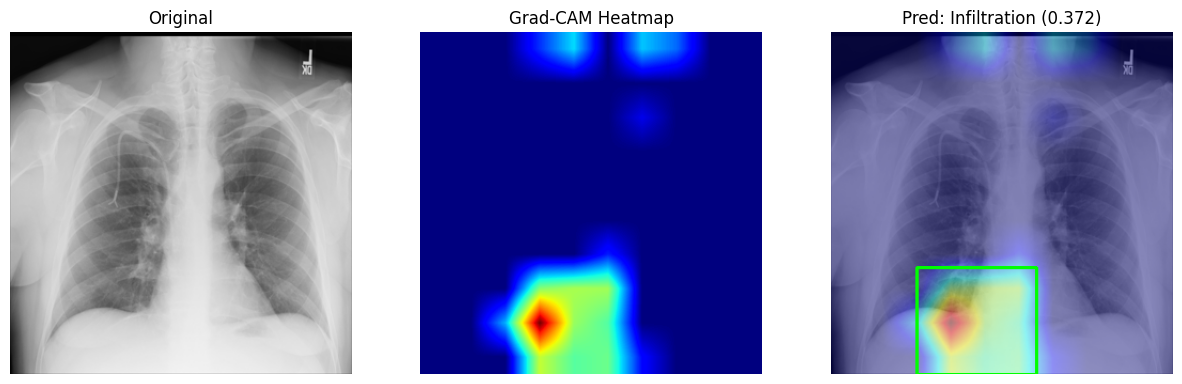

Top 5 predictions:
Infiltration: 0.3718
Atelectasis: 0.3175
Effusion: 0.2987
Mass: 0.2835
Nodule: 0.2599


In [ ]:
sample_path = val_df.iloc[1]["path"]
show_prediction(sample_path)

/var/folders/pv/2c7wbp5n1mbc6csyy99nrfy80000gn/T/ipykernel_13772/1335742068.py:21: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  score.backward(retain_graph=True)


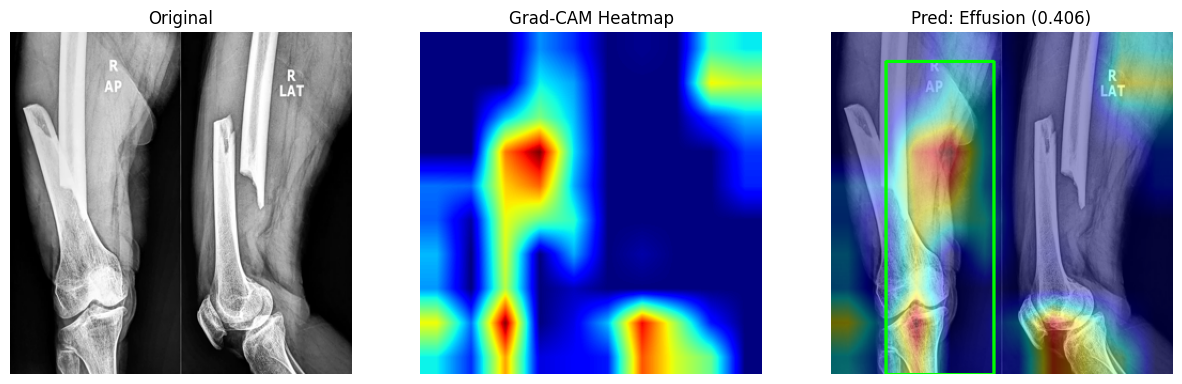

Top 5 predictions:
Effusion: 0.4063
Infiltration: 0.3825
Mass: 0.3178
Fibrosis: 0.2819
Nodule: 0.2504


In [ ]:

sample_path = "/Users/ahsanurrahman/Antigravity/NIH/image copy.png"
show_prediction(sample_path)

Evaluating: 100%|██████████| 2/2 [00:07<00:00,  3.89s/it]

Eval Loss   : 0.0445
Macro mAUC  : nan

Per-class AUC + best threshold:



/Users/ahsanurrahman/Antigravity/NIH/.venv/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/Users/ahsanurrahman/Antigravity/NIH/.venv/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/Users/ahsanurrahman/Antigravity/NIH/.venv/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


,label,auc,best_threshold,youden_j
4,Mass,0.925926,0.283045,0.925926
2,Effusion,0.846939,0.293242,0.632653
1,Cardiomegaly,0.833333,0.274418,0.833333
12,Pleural_Thickening,0.705128,0.213612,0.455128
7,Pneumothorax,0.668000,0.177048,0.400000
8,Consolidation,0.660256,0.191851,0.500000
3,Infiltration,0.636054,0.442688,0.479592
0,Atelectasis,0.532000,0.237162,0.180000
11,Fibrosis,0.245283,0.176072,0.207547
5,Nodule,0.222222,0.197433,0.222222


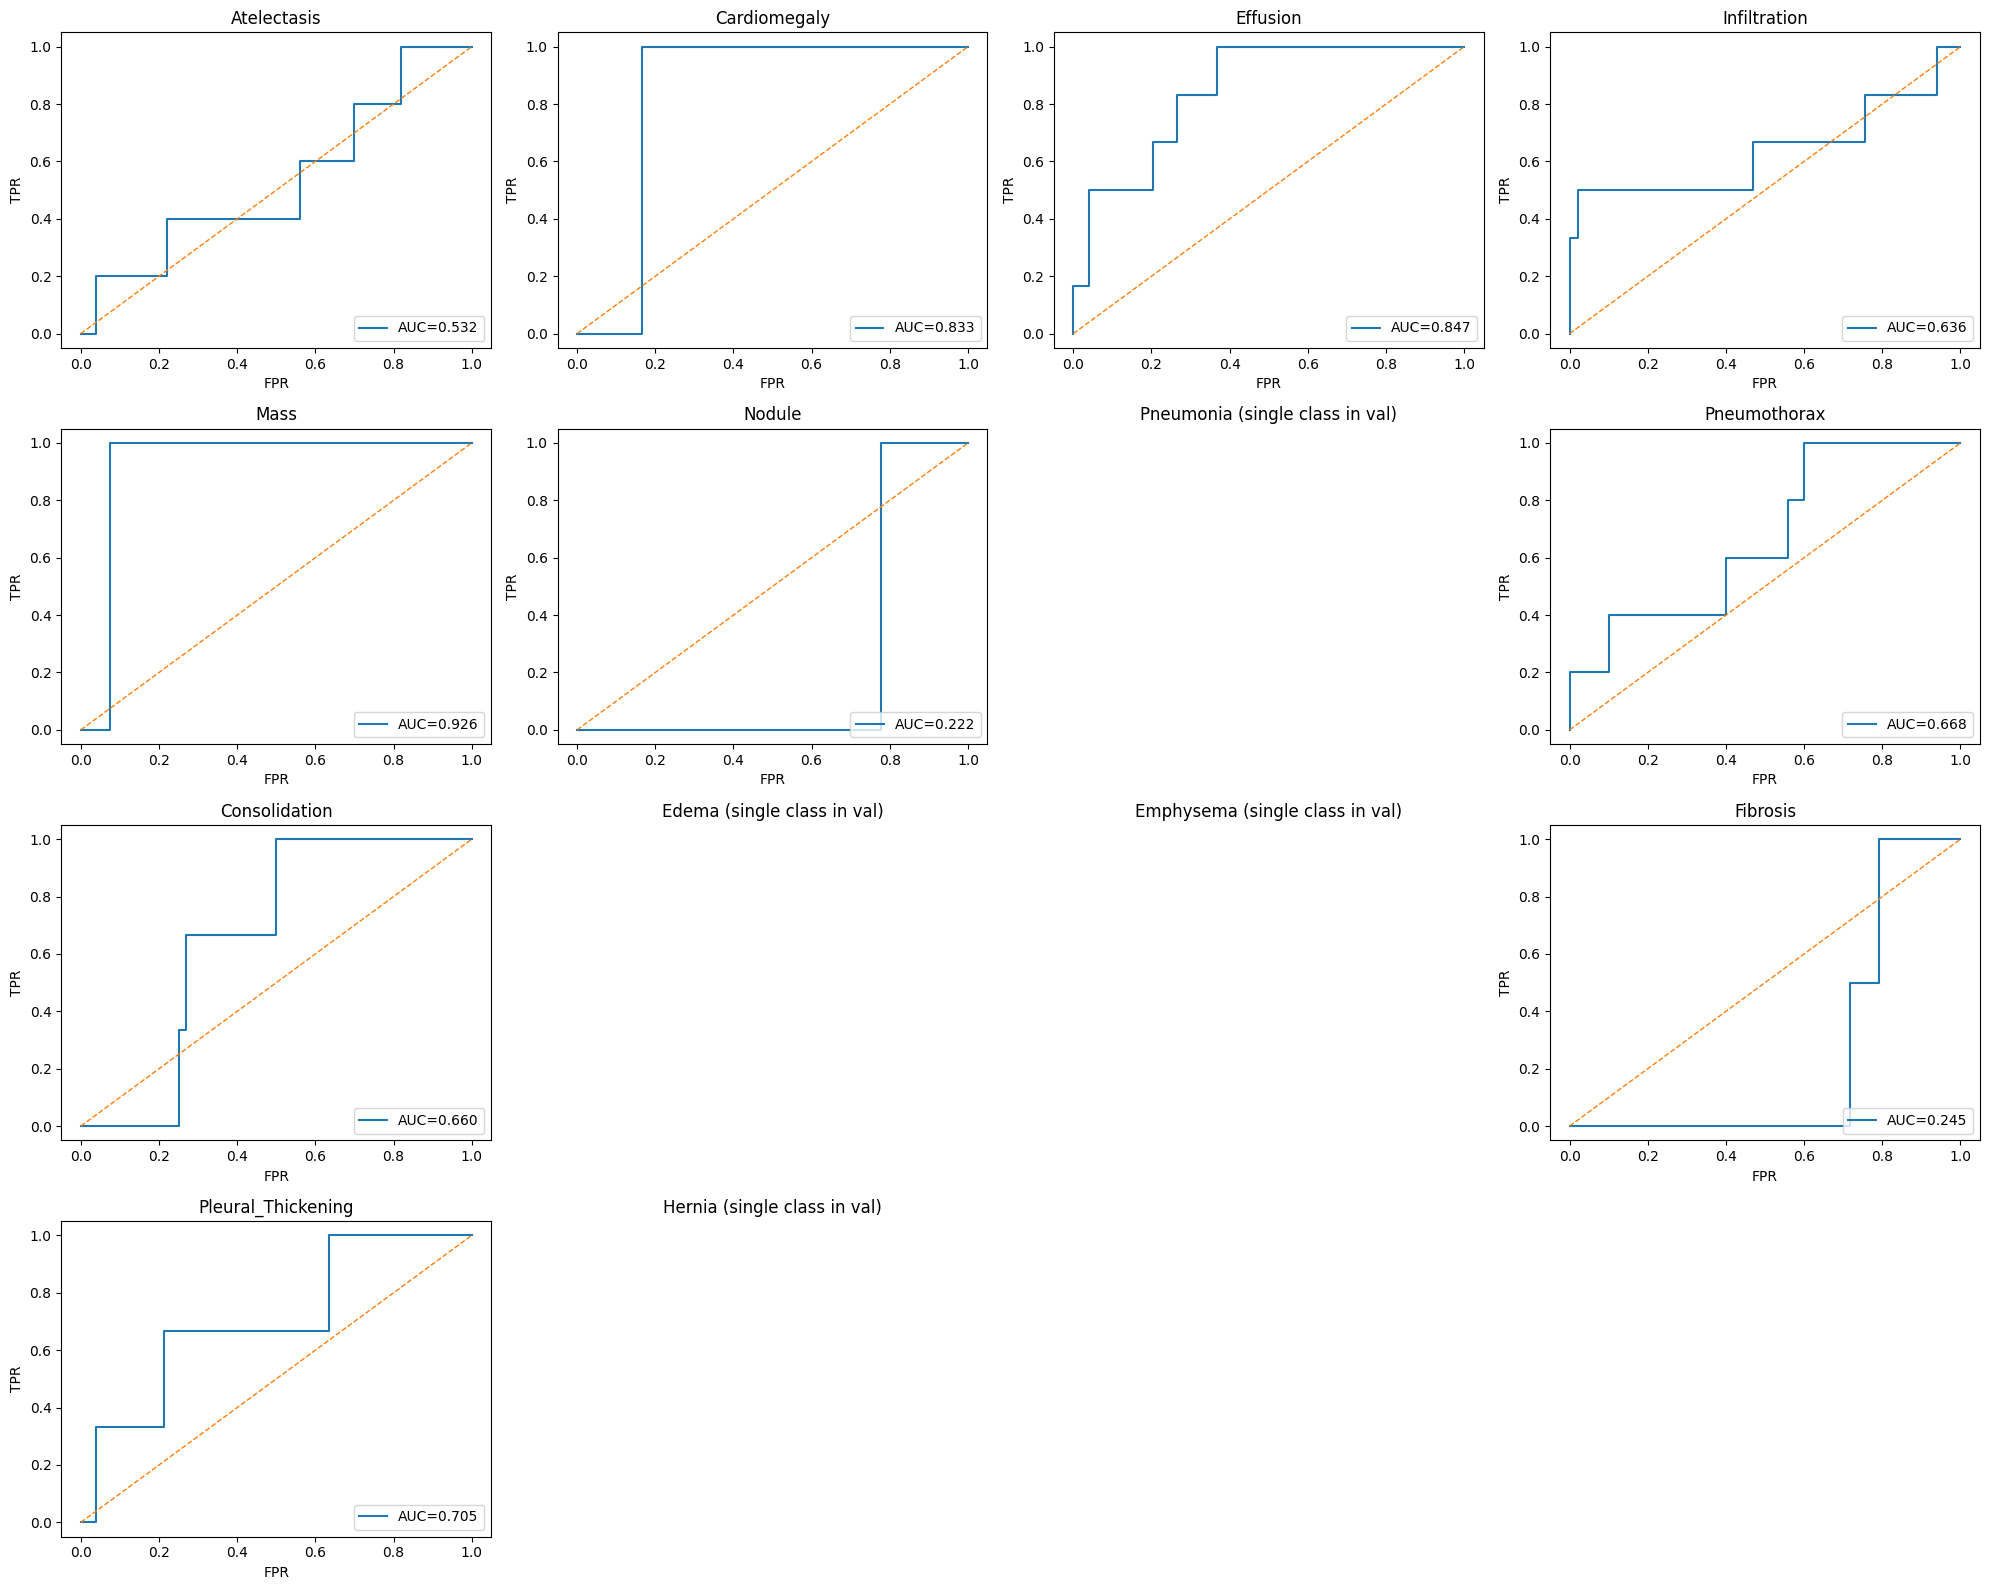

Learning curve not available yet. Please store train_losses, val_losses, val_aucs during training.


In [ ]:
# Full evaluation: macro mAUC, per-class AUC, ROC curves, best threshold/class
from sklearn.metrics import roc_auc_score, roc_curve

@torch.no_grad()
def evaluate_model_full(model, loader, criterion, device, labels):
    model.eval()
    running_loss = 0.0
    all_targets = []
    all_probs = []

    for images, targets, _ in tqdm(loader, desc="Evaluating"):
        images = images.to(device)
        targets = targets.to(device)

        logits = model(images)
        loss = criterion(logits, targets)
        probs = torch.sigmoid(logits)

        running_loss += loss.item() * images.size(0)
        all_targets.append(targets.cpu().numpy())
        all_probs.append(probs.cpu().numpy())

    y_true = np.concatenate(all_targets, axis=0)
    y_prob = np.concatenate(all_probs, axis=0)
    val_loss = running_loss / len(loader.dataset)

    # Overall macro mAUC (fallback if some classes are degenerate)
    try:
        macro_auc = roc_auc_score(y_true, y_prob, average="macro")
    except Exception:
        aucs_tmp = []
        for i in range(y_true.shape[1]):
            if len(np.unique(y_true[:, i])) < 2:
                continue
            aucs_tmp.append(roc_auc_score(y_true[:, i], y_prob[:, i]))
        macro_auc = float(np.mean(aucs_tmp)) if len(aucs_tmp) else 0.0

    rows = []
    roc_data = {}
    for i, name in enumerate(labels):
        y_i = y_true[:, i]
        p_i = y_prob[:, i]

        if len(np.unique(y_i)) < 2:
            rows.append({
                "label": name,
                "auc": np.nan,
                "best_threshold": np.nan,
                "youden_j": np.nan,
            })
            continue

        auc_i = roc_auc_score(y_i, p_i)
        fpr, tpr, thr = roc_curve(y_i, p_i)
        j = tpr - fpr
        best_idx = int(np.argmax(j))
        best_thr = float(thr[best_idx])

        rows.append({
            "label": name,
            "auc": float(auc_i),
            "best_threshold": best_thr,
            "youden_j": float(j[best_idx]),
        })
        roc_data[name] = (fpr, tpr, auc_i)

    results_df = pd.DataFrame(rows).sort_values("auc", ascending=False, na_position="last")
    return val_loss, float(macro_auc), results_df, roc_data

# If you want to evaluate strictly the saved best checkpoint, uncomment:
# model.load_state_dict(torch.load("model/best_densenet_nih.pth", map_location=device))

eval_loss, eval_macro_auc, auc_table, roc_data = evaluate_model_full(
    model, val_loader, criterion, device, all_labels
)

print(f"Eval Loss   : {eval_loss:.4f}")
print(f"Macro mAUC  : {eval_macro_auc:.4f}")
print("\nPer-class AUC + best threshold:")
display(auc_table)

# ROC plots
n = len(all_labels)
cols = 4
rows = int(np.ceil(n / cols))
plt.figure(figsize=(5 * cols, 4 * rows))

for idx, label in enumerate(all_labels, start=1):
    plt.subplot(rows, cols, idx)
    if label in roc_data:
        fpr, tpr, auc_i = roc_data[label]
        plt.plot(fpr, tpr, label=f"AUC={auc_i:.3f}")
        plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
        plt.title(label)
        plt.xlabel("FPR")
        plt.ylabel("TPR")
        plt.legend(loc="lower right")
    else:
        plt.title(f"{label} (single class in val)")
        plt.axis("off")

plt.tight_layout()
plt.show()

# Learning curves (if training history lists are available)
# Expected lists from training loop: train_losses, val_losses, val_aucs
history_ok = all(k in globals() for k in ["train_losses", "val_losses", "val_aucs"])

if history_ok and len(train_losses) > 0:
    epochs = np.arange(1, len(train_losses) + 1)
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))

    ax[0].plot(epochs, train_losses, marker="o", label="Train Loss")
    ax[0].plot(epochs, val_losses, marker="o", label="Val Loss")
    ax[0].set_title("Loss Curve")
    ax[0].set_xlabel("Epoch")
    ax[0].set_ylabel("Loss")
    ax[0].legend()
    ax[0].grid(True, alpha=0.3)

    ax[1].plot(epochs, val_aucs, marker="o", color="green", label="Val mAUC")
    ax[1].set_title("Validation mAUC Curve")
    ax[1].set_xlabel("Epoch")
    ax[1].set_ylabel("mAUC")
    ax[1].legend()
    ax[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("Learning curve not available yet. Please store train_losses, val_losses, val_aucs during training.")